# 02 — Контролируемое дообучение (SFT)

**Этап 2 задания на ВКР:** дообучение Qwen2.5-1.5B на данных дистилляции DeepSeek-R1.

Шаги:

0. Зависимости, GPU, пути, импорты
1. Конфигурация, константы, вспомогательные функции
2. Функция обучения (`train_sft`)
3. Функция оценки (`eval_sft`) — vLLM + кэш генераций
4. Smoke test (c2048_v500, seed=42)
5. ═══ MIN ═══ Полный прогон: обучение (36 конфигураций)
6. ═══ MIN ═══ Полный прогон: оценка
7. Сводная таблица и итоговая проверка

## Шаг 0. Зависимости, GPU, пути, импорты

In [2]:
!pip install -q torch transformers peft trl datasets accelerate scipy

import transformers, peft, trl, datasets
print(f'transformers={transformers.__version__}, peft={peft.__version__}, trl={trl.__version__}, datasets={datasets.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.0/678.0 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 54.4 MB/s eta 0:00:00
transformers=5.0.0, peft=0.18.1, trl=1.1.0, datasets=4.8.4


In [3]:
import torch, os, json, sys, time, re, logging, gc
import numpy as np

assert torch.cuda.is_available(), 'GPU не найден'
print(f'GPU: {torch.cuda.get_device_name(0)}, {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

from google.colab import drive
drive.mount('/content/drive')

# ── Пути (те же, что в 00_setup и 01_data_prep) ──
MODEL_ROOT    = '/content/drive/MyDrive/vkr_models'
DATA_ROOT     = '/content/drive/MyDrive/vkr_data'
RESULTS_ROOT  = '/content/drive/MyDrive/vkr_results'
SUBSETS_DIR   = f'{DATA_ROOT}/subsets'
BASE_MODEL    = f'{MODEL_ROOT}/Qwen2.5-1.5B'

# Новые пути
SFT_MODELS    = f'{MODEL_ROOT}/sft'
SFT_RESULTS   = f'{RESULTS_ROOT}/sft'
GENERATIONS   = f'{RESULTS_ROOT}/sft/generations'
for d in [SFT_MODELS, SFT_RESULTS, GENERATIONS]:
    os.makedirs(d, exist_ok=True)

assert os.path.exists(BASE_MODEL), f'Модель не найдена: {BASE_MODEL}'

# parsing.py из 00_setup
sys.path.insert(0, DATA_ROOT)
import parsing

# Attention backend
try:
    import flash_attn; ATTN_IMPL = 'flash_attention_2'
except ImportError:
    ATTN_IMPL = 'eager'

print(f'Базовая модель: {BASE_MODEL}')
print(f'Attention:      {ATTN_IMPL}')

GPU: NVIDIA A100-SXM4-80GB, 85.1 GB
Mounted at /content/drive
Базовая модель: /content/drive/MyDrive/vkr_models/Qwen2.5-1.5B
Attention:      eager


## Шаг 1. Конфигурация, константы, вспомогательные функции

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed
from peft import LoraConfig, PeftModel
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset, load_from_disk

logging.getLogger('transformers.generation').setLevel(logging.ERROR)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
print(f'Токенизатор: vocab={tokenizer.vocab_size}, EOS={tokenizer.eos_token!r}')

#  Тестовые наборы
ds_gsm8k = load_dataset('openai/gsm8k', 'main', split='test')
ds_math500 = load_dataset('HuggingFaceH4/MATH-500', split='test')
ds_val = load_from_disk(f'{SUBSETS_DIR}/val')
assert len(ds_gsm8k) == 1319 and len(ds_math500) == 500 and len(ds_val) == 500
print(f'GSM8K: {len(ds_gsm8k)}, MATH-500: {len(ds_math500)}, Val: {len(ds_val)}')

# Предвычисляем — не пересоздавать при каждом eval
GSM8K_PROBLEMS = [ex['question'] for ex in ds_gsm8k]
GSM8K_GOLDS    = [parsing.extract_answer_gsm8k(ex['answer']) for ex in ds_gsm8k]
MATH_PROBLEMS  = [ex['problem'] for ex in ds_math500]
MATH_GOLDS     = [ex['answer'] for ex in ds_math500]

#  Эксперимент
THRESHOLDS = [2048, 4096, 8192]
VOLUMES    = [500, 1000, 2000, 5000]
SEEDS      = [42, 43, 44]
ALL_RUNS   = [(f'c{t}_v{v}', s) for t in THRESHOLDS for v in VOLUMES for s in SEEDS]

# SFT гиперпараметры (раздел 3.2 отчёта)
LORA_CONFIG = LoraConfig(
    r=64, lora_alpha=64, target_modules='all-linear',
    lora_dropout=0.0, bias='none', task_type='CAUSAL_LM',
)

SFT_DEFAULTS = dict(
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,   # effective batch = 16
    learning_rate=2e-4,
    max_length=8192,
    bf16=True,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='no',
    report_to='none',
    optim='adamw_torch',
    lr_scheduler_type='cosine',
    warmup_ratio=0.05,
    dataloader_pin_memory=True,
)

PROMPT_SUFFIX = '\n\nPlease reason step by step, and put your final answer within \\boxed{}.'

print(f'LoRA: r={LORA_CONFIG.r}, alpha={LORA_CONFIG.lora_alpha}')
print(f'Effective batch: {SFT_DEFAULTS["per_device_train_batch_size"] * SFT_DEFAULTS["gradient_accumulation_steps"]}')
print(f'lr={SFT_DEFAULTS["learning_rate"]}, epochs={SFT_DEFAULTS["num_train_epochs"]}, max_seq={SFT_DEFAULTS["max_length"]}')
print(f'Прогонов: {len(ALL_RUNS)} (12 подмножеств × 3 seed)')
# Верификация: формат train совпадает с eval
_check = load_from_disk(f'{SUBSETS_DIR}/c2048_v500')
_msg = _check[0]['messages']
assert _msg[0]['role'] == 'user' and PROMPT_SUFFIX.strip() in _msg[0]['content'], \
    f'Train промпт не содержит eval промпт: {_msg[0]["content"][:100]}'
assert _msg[1]['role'] == 'assistant', f'Ожидался assistant, получен {_msg[1]["role"]}'
del _check
print('Train/eval формат: совпадает \u2713')

# Проверка наличия всех подмножеств
_missing = [f'c{t}_v{v}' for t in THRESHOLDS for v in VOLUMES
            if not os.path.exists(f'{SUBSETS_DIR}/c{t}_v{v}')]
assert not _missing, f'Подмножества не найдены: {_missing}'
print(f'Подмножества: все 12 на месте \u2713')

Токенизатор: vocab=151643, EOS='<|endoftext|>'


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/412 [00:00<?, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

GSM8K: 1319, MATH-500: 500, Val: 500
LoRA: r=64, alpha=64
Effective batch: 16
lr=0.0002, epochs=3, max_seq=8192
Прогонов: 36 (12 подмножеств × 3 seed)
Train/eval формат: совпадает ✓
Подмножества: все 12 на месте ✓


Порядок!

- Токенизатор загружен (vocab=151643, EOS=<|endoftext|>)
- GSM8K: 1319, MATH-500: 500, Val: 500 — все три на месте
- LoRA: r=64, alpha=64, effective batch=16, lr=0.0002, epochs=3
- 36 прогонов
- Train/eval формат: совпадает
- Подмножества: все 12 на месте


In [5]:
def is_run_complete(run_name: str) -> bool:
    """Проверка, что  обучение прогона завершилось полностью: конфиг адаптера + веса + лог + токенизатор. Если упвл - False, прогон переобучаем"""
    d = f'{SFT_MODELS}/{run_name}'
    required = ['adapter_config.json', 'training_log.json', 'tokenizer_config.json']
    if not all(os.path.exists(f'{d}/{f}') for f in required):
        return False
    # Проверка весов: safetensors или bin
    has_weights = (os.path.exists(f'{d}/adapter_model.safetensors')
                   or os.path.exists(f'{d}/adapter_model.bin'))
    return has_weights


def score_responses(benchmark: str, responses: list[str]) -> dict:
    """Подсчёт accuracy. Парсер: только \\boxed{} — единый для обоих бенчмарков.
       Для GSM8K — числовое сравнение (is_correct_gsm8k), для MATH — символьная эквивалентность (is_equiv).
    """
    results = []
    golds = GSM8K_GOLDS if benchmark == 'gsm8k' else MATH_GOLDS

    for resp, gold in zip(responses, golds):
        pred = parsing.extract_answer_math(resp)
        if benchmark == 'gsm8k':
            correct = parsing.is_correct_gsm8k(pred, gold) if pred is not None else False
        else:
            correct = parsing.is_equiv(pred, gold) if pred is not None else False
        results.append({'correct': correct, 'pred': pred, 'none': pred is None})

    correct = [r['correct'] for r in results]
    acc, lo, hi = parsing.bootstrap_ci(correct)
    none_rate = sum(r['none'] for r in results) / len(results)
    return {'accuracy': acc, 'ci': [lo, hi], 'none_rate': none_rate, '_raw': results}


def build_result_json(run_name: str, eval_info: dict) -> dict:
    """Формирование JSON для сохранения
       дл одного прогона: конфиг, train/val loss из лога, accuracy обоих бенчмарков.
    """
    subset, seed_str = run_name.rsplit('_s', 1)

    log_path = f'{SFT_MODELS}/{run_name}/training_log.json'
    train_loss, val_loss = None, None
    if os.path.exists(log_path):
        with open(log_path) as f:
            log_history = json.load(f)
        train_losses = [e['loss'] for e in log_history if 'loss' in e]
        eval_losses = [e['eval_loss'] for e in log_history if 'eval_loss' in e
                       and not np.isnan(e['eval_loss'])]
        train_loss = train_losses[-1] if train_losses else None
        val_loss = eval_losses[-1] if eval_losses else None
    else:
        print(f'  \u26a0 {log_path} не найден, train метрики = None')

    return {
        'config': {
            'subset': subset, 'seed': int(seed_str),
            'lora_r': LORA_CONFIG.r, 'lr': SFT_DEFAULTS['learning_rate'],
            'epochs': SFT_DEFAULTS['num_train_epochs'],
            'effective_batch': SFT_DEFAULTS['per_device_train_batch_size'] * SFT_DEFAULTS['gradient_accumulation_steps'],
        },
        'train': {'final_train_loss': train_loss, 'final_val_loss': val_loss},
        'gsm8k': {k: v for k, v in eval_info['gsm8k'].items() if k != '_raw'},
        'math500': {k: v for k, v in eval_info['math500'].items() if k != '_raw'},
    }


print('Вспомогательные функции определены')

Вспомогательные функции определены


## Шаг 2. Функция обучения (`train_sft`)

In [6]:
def train_sft(subset_name: str, seed: int) -> dict:
    """Обучение LoRA-адаптера. Если все артефакты на месте — пропускает."""
    run_name = f'{subset_name}_s{seed}'
    adapter_dir = f'{SFT_MODELS}/{run_name}'

    if is_run_complete(run_name):
        print(f'[{run_name}] прогон завершён, пропуск')
        with open(f'{adapter_dir}/training_log.json') as f:
            log = json.load(f)
        eval_losses = [e['eval_loss'] for e in log if 'eval_loss' in e
                       and not np.isnan(e['eval_loss'])]
        return {'run_name': run_name, 'skipped': True,
                'final_val_loss': eval_losses[-1] if eval_losses else None}

    ds_train = load_from_disk(f'{SUBSETS_DIR}/{subset_name}')
    print(f'[{run_name}] train={len(ds_train)}, val={len(ds_val)}')

    set_seed(seed)
    model = None
    trainer = None
    try:
        model = AutoModelForCausalLM.from_pretrained(
            BASE_MODEL, torch_dtype=torch.bfloat16, attn_implementation=ATTN_IMPL)

        trainer = SFTTrainer(
            model=model,
            args=SFTConfig(output_dir=f'/content/sft_tmp/{run_name}', seed=seed, **SFT_DEFAULTS),
            train_dataset=ds_train,
            eval_dataset=ds_val,
            peft_config=LORA_CONFIG,
            processing_class=tokenizer,
        )

        t0 = time.time()
        trainer.train()
        duration = time.time() - t0

        log = trainer.state.log_history
        train_losses = [e['loss'] for e in log if 'loss' in e]
        eval_losses = [e['eval_loss'] for e in log if 'eval_loss' in e
                       and not np.isnan(e['eval_loss'])]

        trainer.save_model(adapter_dir)
        tokenizer.save_pretrained(adapter_dir)
        with open(f'{adapter_dir}/training_log.json', 'w') as f:
            json.dump(log, f, indent=2)

        final_tl = train_losses[-1] if train_losses else None
        final_vl = eval_losses[-1] if eval_losses else None
        print(f'[{run_name}] {duration/60:.1f} мин, train_loss={final_tl}, val_loss={final_vl}')

        return {'run_name': run_name, 'skipped': False, 'duration_min': round(duration/60, 1),
                    'final_train_loss': final_tl, 'final_val_loss': final_vl,
                    'log': log}

    finally:
        del trainer, model
        gc.collect()
        torch.cuda.empty_cache()

## Шаг 3. Функция оценки (eval_sft) — HF generate + кэш генераций

Генерации кэшируются на Drive — при падении Colab не перегенерировать.
Кэш переиспользуется в 04_inference.

In [ ]:
# ═══ НЕ ЗАПУСКАТЬ ДО ОКОНЧАНИЯ ОБУЧЕНИЯ ═══
# vLLM конфликтует с transformers 4.x. Ставить ПОСЛЕ Шага 5.
# !pip install -q vllm
# import vllm
# print(f"vllm={vllm.__version__}")


vllm=0.19.0


In [ ]:
# ═══ НЕ ЗАПУСКАТЬ ДО ОКОНЧАНИЯ ОБУЧЕНИЯ ═══
# Запустить ПОСЛЕ Шага 5 (обучение), ПЕРЕД Шагом 6 (оценка).
# # ── Раскомментить для работы с vLLM

# from vllm import LLM, SamplingParams
# from vllm.lora.request import LoRARequest

# EVAL_SAMPLING = SamplingParams(
#     temperature=0.0, max_tokens=4096,
#     stop=['<|im_end|>', '<|endoftext|>'],
# )

# _lora_id = 0

# CACHE_META = {
#     'base_model': BASE_MODEL.split('/')[-1],
#     'prompt_suffix': PROMPT_SUFFIX,
#     'max_tokens': EVAL_SAMPLING.max_tokens,
#     'temperature': EVAL_SAMPLING.temperature,
# }

# def load_vllm_engine():
#     return LLM(
#         model=BASE_MODEL, dtype='bfloat16',
#         enable_lora=True, max_lora_rank=64,
#         max_model_len=8192, gpu_memory_utilization=0.9,
#     )


# def _build_prompts(problems: list[str]) -> list[str]:
#     return [
#         tokenizer.apply_chat_template(
#             [{'role': 'user', 'content': p + PROMPT_SUFFIX}],
#             tokenize=False, add_generation_prompt=True)
#         for p in problems
#     ]


# def _is_cache_valid(cached, n_problems: int) -> bool:
#     #Проверка кэша: формат, мета, длина.
#     if not isinstance(cached, dict):
#         return False
#     saved = cached.get('meta', {})
#     # Все поля CACHE_META должны совпадать
#     if any(saved.get(k) != v for k, v in CACHE_META.items()):
#         return False
#     return len(cached.get('responses', [])) == n_problems


# def generate_cached(engine, run_name: str, benchmark: str,
#                     problems: list[str], lora_path: str) -> list[str]:
#     #Генерация с кэшем на Drive. Кэш = meta + responses.
#     global _lora_id
#     cache_path = f'{GENERATIONS}/{run_name}_{benchmark}.json'

#     if os.path.exists(cache_path):
#         with open(cache_path) as f:
#             cached = json.load(f)
#         if _is_cache_valid(cached, len(problems)):
#             print(f'  [{benchmark}] кэш: {len(cached["responses"])} генераций')
#             return cached['responses']
#         print(f'  [{benchmark}] кэш невалиден, перегенерируем')

#     _lora_id += 1
#     lora_req = LoRARequest(run_name, _lora_id, lora_path)
#     outputs = engine.generate(_build_prompts(problems), EVAL_SAMPLING, lora_request=lora_req)
#     responses = [o.outputs[0].text for o in outputs]

#     with open(cache_path, 'w') as f:
#         json.dump({'meta': {**CACHE_META, 'run_name': run_name, 'benchmark': benchmark},
#                    'responses': responses}, f, ensure_ascii=False)
#     print(f'  [{benchmark}] сгенерировано: {len(responses)}')
#     return responses


# def eval_sft(engine, run_name: str) -> dict:
#     #Генерация (с кэшем) + scoring для GSM8K и MATH-500.
#     adapter_dir = f'{SFT_MODELS}/{run_name}'
#     gsm_resp = generate_cached(engine, run_name, 'gsm8k', GSM8K_PROBLEMS, adapter_dir)
#     math_resp = generate_cached(engine, run_name, 'math500', MATH_PROBLEMS, adapter_dir)
#     return {
#         'gsm8k': score_responses('gsm8k', gsm_resp),
#         'math500': score_responses('math500', math_resp),
#     }


# print('vLLM функции определены')



vLLM функции определены


### 3.1. Фоллбэк без vLLM

Раскомментировать, если vLLM не установился. Медленнее (~25 мин/модель), но работает.

In [ ]:
# ═══ HF FALLBACK — НЕ ЗАПУСКАТЬ ═══
# Используется только если vLLM не работает.
# # ── Раскомментить, если vLLM не работает
# from tqdm import tqdm

# STOP_IDS = [tokenizer.convert_tokens_to_ids(t) for t in ['<|endoftext|>', '<|im_end|>']]

# CACHE_META = {
#     'base_model': BASE_MODEL.split('/')[-1],
#     'prompt_suffix': PROMPT_SUFFIX,
#     'max_tokens': 4096,
#     'temperature': 0.0,
# }


# def _load_cache(run_name, benchmark, n_problems):
#     path = f'{GENERATIONS}/{run_name}_{benchmark}.json'
#     if not os.path.exists(path):
#         return None
#     with open(path) as f:
#         cached = json.load(f)
#     if not isinstance(cached, dict):
#         return None
#     saved = cached.get('meta', {})
#     if any(saved.get(k) != v for k, v in CACHE_META.items()):
#         return None
#     resps = cached.get('responses', [])
#     return resps if len(resps) == n_problems else None


# def _save_cache(run_name, benchmark, responses):
#     with open(f'{GENERATIONS}/{run_name}_{benchmark}.json', 'w') as f:
#         json.dump({'meta': {**CACHE_META, 'run_name': run_name, 'benchmark': benchmark},
#                    'responses': responses}, f, ensure_ascii=False)


# def _generate(model, problems, bs=16, max_new_tokens=4096):
#     tokenizer.padding_side = 'left'
#     if tokenizer.pad_token is None:
#         tokenizer.pad_token = tokenizer.eos_token
#     results = []
#     for i in tqdm(range(0, len(problems), bs)):
#         texts = [tokenizer.apply_chat_template(
#             [{'role': 'user', 'content': p + PROMPT_SUFFIX}],
#             tokenize=False, add_generation_prompt=True) for p in problems[i:i+bs]]
#         inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=2048)
#         inputs = {k: v.to(model.device) for k, v in inputs.items()}
#         with torch.no_grad():
#             out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, eos_token_id=STOP_IDS)
#         plen = inputs['input_ids'].shape[1]
#         results.extend(tokenizer.decode(out[j, plen:], skip_special_tokens=True) for j in range(out.shape[0]))
#     return results


# def eval_sft(_, run_name):
#     gsm = _load_cache(run_name, 'gsm8k', len(GSM8K_PROBLEMS))
#     math = _load_cache(run_name, 'math500', len(MATH_PROBLEMS))

#     if gsm is not None and math is not None:
#         print(f'  [кэш] gsm8k={len(gsm)}, math500={len(math)}')
#         return {'gsm8k': score_responses('gsm8k', gsm), 'math500': score_responses('math500', math)}

#     model = AutoModelForCausalLM.from_pretrained(BASE_MODEL, torch_dtype=torch.bfloat16, device_map='auto')
#     model = PeftModel.from_pretrained(model, f'{SFT_MODELS}/{run_name}')
#     model.eval()
#     try:
#         if gsm is None:
#             gsm = _generate(model, GSM8K_PROBLEMS)
#             _save_cache(run_name, 'gsm8k', gsm)
#         if math is None:
#             math = _generate(model, MATH_PROBLEMS)
#             _save_cache(run_name, 'math500', math)
#     finally:
#         del model; gc.collect(); torch.cuda.empty_cache()

#     return {'gsm8k': score_responses('gsm8k', gsm), 'math500': score_responses('math500', math)}


# def load_vllm_engine():
#     return None


# print('Eval функции определены (HF generate)')


Eval функции определены (HF generate)


## Шаг 4. Smoke test (c2048_v500, seed=42)

обучение

In [7]:
smoke_train = train_sft('c2048_v500', seed=42)

[c2048_v500_s42] прогон завершён, пропуск


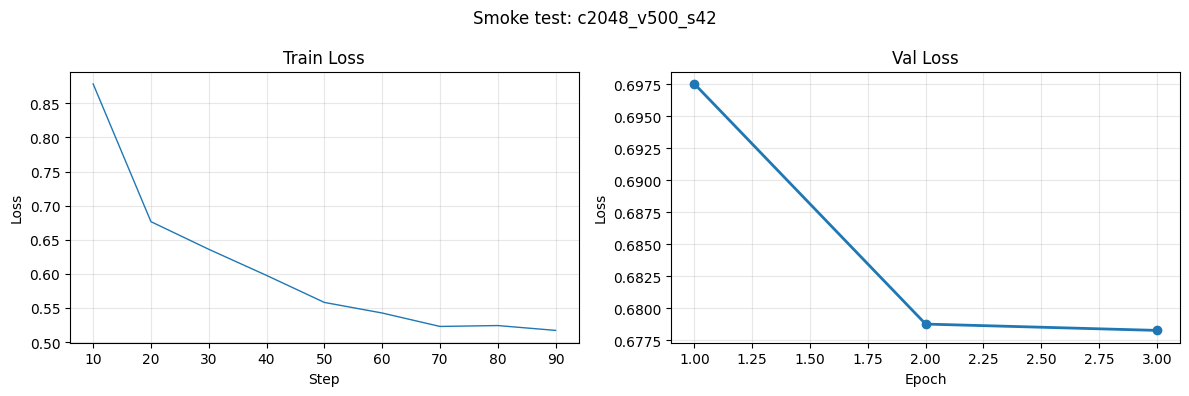

Final: train_loss=0.5171, val_loss=0.6783


In [8]:
import matplotlib.pyplot as plt

log = smoke_train.get('log') or json.load(open(f'{SFT_MODELS}/c2048_v500_s42/training_log.json'))
tl = [(e['step'], e['loss']) for e in log if 'loss' in e]
vl = [(e['epoch'], e['eval_loss']) for e in log if 'eval_loss' in e]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(*zip(*tl), lw=1); ax1.set(xlabel='Step', ylabel='Loss', title='Train Loss'); ax1.grid(alpha=0.3)
ax2.plot(*zip(*vl), 'o-', lw=2); ax2.set(xlabel='Epoch', ylabel='Loss', title='Val Loss'); ax2.grid(alpha=0.3)
fig.suptitle('Smoke test: c2048_v500_s42'); plt.tight_layout(); plt.show()
print(f'Final: train_loss={tl[-1][1]:.4f}, val_loss={vl[-1][1]:.4f}')

проверка 5 задач

 Лимит генерации 4096 токенов задан как аварийный потолок. Генерация завершается по стоп-токену <|im_end|>, фактическая длина определяется моделью.

In [ ]:
model = AutoModelForCausalLM.from_pretrained(BASE_MODEL, torch_dtype=torch.bfloat16, device_map='auto')
model = PeftModel.from_pretrained(model, f'{SFT_MODELS}/c2048_v500_s42')
model.eval()

resps = _generate(model, GSM8K_PROBLEMS[:5])
for i, resp in enumerate(resps):
    pred = parsing.extract_answer_math(resp)
    correct = parsing.is_correct_gsm8k(pred, GSM8K_GOLDS[i]) if pred else False
    print(f'--- Задача {i}: gold={GSM8K_GOLDS[i]}, pred={pred}, correct={correct} ---')
    print(resp[:300])
    print()

del model; gc.collect(); torch.cuda.empty_cache()

полный eval

In [ ]:
gc.collect()
torch.cuda.empty_cache()
print(f'GPU свободно: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

GPU свободно: 84.5 GB


In [ ]:
engine = load_vllm_engine()
smoke_eval = eval_sft(engine, 'c2048_v500_s42')

Rendering prompts:   0%|          | 0/1319 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1319 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

  [gsm8k] сгенерировано: 1319


Rendering prompts:   0%|          | 0/500 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/500 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  [math500] сгенерировано: 500


диагностика

In [ ]:
gsm = smoke_eval['gsm8k']
math = smoke_eval['math500']
print(f'GSM8K:    acc={gsm["accuracy"]:.3f} [{gsm["ci"][0]:.3f}, {gsm["ci"][1]:.3f}]  none_rate={gsm["none_rate"]:.1%}')
print(f'MATH-500: acc={math["accuracy"]:.3f} [{math["ci"][0]:.3f}, {math["ci"][1]:.3f}]  none_rate={math["none_rate"]:.1%}')

for label, bm_key, scores in [('GSM8K', 'gsm8k', gsm), ('MATH-500', 'math500', math)]:
    nones = [(i, r) for i, r in enumerate(scores['_raw']) if r['none']]
    if nones:
        cache = json.load(open(f'{GENERATIONS}/c2048_v500_s42_{bm_key}.json'))
        resps = cache['responses'] if isinstance(cache, dict) else cache
        print(f'\n⚠ {label}: {len(nones)} неразобранных ({len(nones)/len(scores["_raw"]):.1%})')
        for idx, _ in nones[:3]:
            print(f'  [{idx}] ...{resps[idx][-200:]}')
    else:
        print(f'{label}: none_rate=0 ✓')

GSM8K:    acc=0.415 [0.388, 0.442]  none_rate=38.4%
MATH-500: acc=0.264 [0.226, 0.302]  none_rate=54.8%

⚠ GSM8K: 506 неразобранных (38.4%)
  [4] ... no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait, no. Wait,
  [7] ... straightforward. Let me check again.

Alternatively, maybe the restart is part of the total time? Wait, no. The restart is a separate event. So, the total time is the time to download 40% of the file
  [8] ...t 80 mph. So, total driving time is 2 + 0.5 + 4 = 6.5 hours. But the problem says he tries to get home in 4 hours, so maybe the 4 hours is the total time he has, but he spends 6.5 hours driving? Wait,

⚠ MATH-500: 274 неразобранных (54.8%)
  [1] ... the double sum is equal to 2 times the sum over all j and k from 1 to ∞ of 1/(j + k)^3. 

But the sum over all j and k from 1 to ∞ is the same as the sum over all j from 1 to ∞ and 

**Результат smoke test c2048_v500:** none_rate 38% (GSM8K) и 55% (MATH-500) — ожидаемое поведение для минимального подмножества. Модель зацикливается в `<think>` и не доходит до `\boxed{}`. Причина: SFT-дистилляция на малом объёме данных с короткими цепочками не обучает модель останавливаться (arXiv:2505.07961). С ростом данных (v1000→v5000) и длин цепочек (c4096, c8192) none_rate снизится. GRPO на следующем этапе решает проблему остановки.

сохранение

In [ ]:
result = build_result_json('c2048_v500_s42', smoke_eval)
with open(f'{SFT_RESULTS}/c2048_v500_s42.json', 'w') as f:
    json.dump(result, f, indent=2)
print(f'Сохранено: {SFT_RESULTS}/c2048_v500_s42.json')

Сохранено: /content/drive/MyDrive/vkr_results/sft/c2048_v500_s42.json


## Шаг 5. ═══ MIN ═══ Полный прогон: обучение

Порядок: по подмножествам, 3 seed подряд. Если адаптер есть — пропуск.

In [10]:
# GPU: освободить память перед обучением
if "engine" in dir():
    del engine
gc.collect()
torch.cuda.empty_cache()
print(f"GPU свободно: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")


GPU свободно: 81.2 GB


In [11]:
todo_train = [(s, sd) for s, sd in ALL_RUNS if not is_run_complete(f'{s}_s{sd}')]
print(f'Всего: {len(ALL_RUNS)}, готово: {len(ALL_RUNS)-len(todo_train)}, осталось: {len(todo_train)}')

Всего: 36, готово: 22, осталось: 14


In [ ]:
for i, (subset, seed) in enumerate(todo_train):
    print(f'\n[{i+1}/{len(todo_train)}] {subset}_s{seed}')
    train_sft(subset, seed)

print('\nОбучение завершено')


[1/14] c4096_v5000_s43
[c4096_v5000_s43] train=5000, val=500


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss
1,0.549979,0.601865
2,0.483198,0.588136
3,0.436669,0.592045


[c4096_v5000_s43] 194.0 мин, train_loss=0.43666877746582033, val_loss=0.5920450687408447

[2/14] c4096_v5000_s44
[c4096_v5000_s44] train=5000, val=500


...

Epoch,Training Loss,Validation Loss
1,0.618307,0.639765
2,0.578414,0.621693
3,0.570961,0.621292


[c8192_v1000_s42] 97.0 мин, train_loss=0.5709607601165771, val_loss=0.621291995048523

[7/14] c8192_v1000_s43
[c8192_v1000_s43] train=1000, val=500


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss
1,0.625282,0.639405


## Шаг 6. ═══ MIN ═══ Полный прогон: оценка

**ПЕРЕД запуском:** установить vLLM и определить функции.
vLLM ставится ПОСЛЕ обучения, чтобы не сломать transformers.


In [ ]:
# ═══ Установка vLLM + определение eval-функций ═══
# vLLM ставится ПОСЛЕ обучения, чтобы не конфликтовать с transformers
!pip install -q vllm


from vllm import LLM, SamplingParams
from vllm.lora.request import LoRARequest

EVAL_SAMPLING = SamplingParams(
    temperature=0.0, max_tokens=4096,
    stop=['<|im_end|>', '<|endoftext|>'],
)

_lora_id = 0

CACHE_META = {
    'base_model': BASE_MODEL.split('/')[-1],
    'prompt_suffix': PROMPT_SUFFIX,
    'max_tokens': EVAL_SAMPLING.max_tokens,
    'temperature': EVAL_SAMPLING.temperature,
}

def load_vllm_engine():
    return LLM(
        model=BASE_MODEL, dtype='bfloat16',
        enable_lora=True, max_lora_rank=64,
        max_model_len=8192, gpu_memory_utilization=0.9,
    )


def _build_prompts(problems: list[str]) -> list[str]:
    return [
        tokenizer.apply_chat_template(
            [{'role': 'user', 'content': p + PROMPT_SUFFIX}],
            tokenize=False, add_generation_prompt=True)
        for p in problems
    ]


def _is_cache_valid(cached, n_problems: int) -> bool:
    #Проверка кэша: формат, мета, длина.
    if not isinstance(cached, dict):
        return False
    saved = cached.get('meta', {})
    # Все поля CACHE_META должны совпадать
    if any(saved.get(k) != v for k, v in CACHE_META.items()):
        return False
    return len(cached.get('responses', [])) == n_problems


def generate_cached(engine, run_name: str, benchmark: str,
                    problems: list[str], lora_path: str) -> list[str]:
    #Генерация с кэшем на Drive. Кэш = meta + responses.
    global _lora_id
    cache_path = f'{GENERATIONS}/{run_name}_{benchmark}.json'

    if os.path.exists(cache_path):
        with open(cache_path) as f:
            cached = json.load(f)
        if _is_cache_valid(cached, len(problems)):
            print(f'  [{benchmark}] кэш: {len(cached["responses"])} генераций')
            return cached['responses']
        print(f'  [{benchmark}] кэш невалиден, перегенерируем')

    _lora_id += 1
    lora_req = LoRARequest(run_name, _lora_id, lora_path)
    outputs = engine.generate(_build_prompts(problems), EVAL_SAMPLING, lora_request=lora_req)
    responses = [o.outputs[0].text for o in outputs]

    with open(cache_path, 'w') as f:
        json.dump({'meta': {**CACHE_META, 'run_name': run_name, 'benchmark': benchmark},
                   'responses': responses}, f, ensure_ascii=False)
    print(f'  [{benchmark}] сгенерировано: {len(responses)}')
    return responses


def eval_sft(engine, run_name: str) -> dict:
    #Генерация (с кэшем) + scoring для GSM8K и MATH-500.
    adapter_dir = f'{SFT_MODELS}/{run_name}'
    gsm_resp = generate_cached(engine, run_name, 'gsm8k', GSM8K_PROBLEMS, adapter_dir)
    math_resp = generate_cached(engine, run_name, 'math500', MATH_PROBLEMS, adapter_dir)
    return {
        'gsm8k': score_responses('gsm8k', gsm_resp),
        'math500': score_responses('math500', math_resp),
    }


print('vLLM функции определены')

engine = load_vllm_engine()
print("vLLM engine загружен ✓")


In [ ]:
todo_eval = [(s, sd) for s, sd in ALL_RUNS
             if not os.path.exists(f'{SFT_RESULTS}/{s}_s{sd}.json')]
print(f'Eval: готово {len(ALL_RUNS)-len(todo_eval)}, осталось {len(todo_eval)}')

In [ ]:
for i, (subset, seed) in enumerate(todo_eval):
    run_name = f'{subset}_s{seed}'
    print(f'\n[{i+1}/{len(todo_eval)}] {run_name}')

    info = eval_sft(engine, run_name)
    gsm, math = info['gsm8k'], info['math500']
    print(f'  GSM8K={gsm["accuracy"]:.3f} [{gsm["ci"][0]:.3f},{gsm["ci"][1]:.3f}]  MATH={math["accuracy"]:.3f} [{math["ci"][0]:.3f},{math["ci"][1]:.3f}]')

    result = build_result_json(run_name, info)
    with open(f'{SFT_RESULTS}/{run_name}.json', 'w') as f:
        json.dump(result, f, indent=2)

print('\nEval завершён')

## Шаг 7. Сводная таблица и итоговая проверка

In [ ]:
# Загрузка всех результатов
results = {}
for sub, seed in ALL_RUNS:
    name = f'{sub}_s{seed}'
    path = f'{SFT_RESULTS}/{name}.json'
    if os.path.exists(path):
        with open(path) as f:
            results[name] = json.load(f)

print(f'Результатов: {len(results)}/{len(ALL_RUNS)}')

if results:
    def _sort_key(name):
        parts = name.split('_')  # c2048, v500, s42
        return (int(parts[0][1:]), int(parts[1][1:]), int(parts[2][1:]))

    print(f'\n{"run":<22s} │ {"train_L":>7s} │ {"val_L":>7s} │ {"GSM8K":>7s} │ {"MATH":>7s}')
    print('─' * 58)
    prev = ''
    for name in sorted(results, key=_sort_key):
        r = results[name]
        prefix = '_'.join(name.split('_')[:2])
        if prev and prefix != prev: print('─' * 58)
        prev = prefix
        print(f'{name:<22s} │ {r["train"]["final_train_loss"]:>7.4f} │ {r["train"]["final_val_loss"]:>7.4f} │ {r["gsm8k"]["accuracy"]:>7.3f} │ {r["math500"]["accuracy"]:>7.3f}')

In [ ]:
# Средние по seed
if len(results) >= 3:
    print(f'\n{"subset":<16s} │ {"GSM8K":>14s} │ {"MATH-500":>14s} │ {"val_loss":>10s}')
    print('─' * 60)
    for t in THRESHOLDS:
        for v in VOLUMES:
            key = f'c{t}_v{v}'
            runs = [results[f'{key}_s{s}'] for s in SEEDS if f'{key}_s{s}' in results]
            if not runs: continue
            ga = [r['gsm8k']['accuracy'] for r in runs]
            ma = [r['math500']['accuracy'] for r in runs]
            vl = [r['train']['final_val_loss'] for r in runs]
            print(f'{key:<16s} │ {np.mean(ga):.3f} ± {np.std(ga):.3f} │ {np.mean(ma):.3f} ± {np.std(ma):.3f} │ {np.mean(vl):.4f}')
        if t != THRESHOLDS[-1]: print('─' * 60)

In [ ]:
# Итоговая проверка
checks = []
for sub, seed in ALL_RUNS:
    name = f'{sub}_s{seed}'
    checks.append((f'{name} обучение', is_run_complete(name)))
    checks.append((f'{name} результат', os.path.exists(f'{SFT_RESULTS}/{name}.json')))
    checks.append((f'{name} кэш gsm8k', os.path.exists(f'{GENERATIONS}/{name}_gsm8k.json')))
    checks.append((f'{name} кэш math',  os.path.exists(f'{GENERATIONS}/{name}_math500.json')))

ok = sum(v for _, v in checks)
fail = [(k, v) for k, v in checks if not v]
print(f'Проверки: {ok}/{len(checks)}')
if fail:
    for k, _ in fail[:10]: print(f'  \u2717 {k}')
    if len(fail) > 10: print(f'  ... и ещё {len(fail)-10}')
else:
    print('Все 36 прогонов завершены \u2713')